In [1]:
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

BASE_DIR    = Path().resolve().parent.parent
DATA_DIR    = BASE_DIR / 'data'
FIGURES_DIR = BASE_DIR / 'figures' / 'conclusions'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Projeto em  : {BASE_DIR}')
print(f'Dados em    : {DATA_DIR}')
print(f'Figuras em  : {FIGURES_DIR}')

/tmp/ipykernel_26439/847610318.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Projeto em  : /home/edson-luiz/Projetos/TCC
Dados em    : /home/edson-luiz/Projetos/TCC/data
Figuras em  : /home/edson-luiz/Projetos/TCC/figures/conclusions


## Paleta de cores e configuracoes visuais

In [2]:
NAVY   = '#1C2B4A'
TEAL   = '#0891B2'
BLUE   = '#2563EB'
GRAY   = '#64748B'
RED    = '#DC2626'
ORANGE = '#F59E0B'

MODEL_COLORS = {
    'Naive Bayes':         NAVY,
    'SVM':                 TEAL,
    'Random Forest':       BLUE,
    'Regressao Logistica': GRAY,
}

MODEL_MARKERS = {
    'Naive Bayes':         'o',
    'SVM':                 's',
    'Random Forest':       'D',
    'Regressao Logistica': '^',
}

TRUNCATION_LENGTHS = [25, 50, 75, 100, 125, 150, 200, 300, 500, None]

MODELS = {
    'Naive Bayes':         MultinomialNB(),
    'SVM':                 LinearSVC(random_state=42, max_iter=2000, dual='auto'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

print('Comprimentos de truncagem a testar:', [t if t else 'Completo' for t in TRUNCATION_LENGTHS])
print(f'Modelos: {list(MODELS.keys())}')

Comprimentos de truncagem a testar: [25, 50, 75, 100, 125, 150, 200, 300, 500, 'Completo']
Modelos: ['Naive Bayes', 'SVM', 'Random Forest', 'Regressao Logistica']


## Carregamento e deteccao automatica de colunas

In [3]:
TREC_CSV = DATA_DIR / 'trec_2007.csv'
df_raw = pd.read_csv(TREC_CSV, encoding='latin-1', on_bad_lines='skip')

print(f'Shape: {df_raw.shape}')
print(f'Colunas: {df_raw.columns.tolist()}')

TEXT_CANDIDATES  = ['body', 'message', 'text', 'email', 'content', 'mail']
LABEL_CANDIDATES = ['label', 'spam', 'class', 'category', 'spam/ham', 'type', 'tag']

cols_lower = {c.lower(): c for c in df_raw.columns}

text_col  = next((cols_lower[c] for c in TEXT_CANDIDATES  if c in cols_lower), None)
label_col = next((cols_lower[c] for c in LABEL_CANDIDATES if c in cols_lower), None)

if text_col is None:
    str_cols = df_raw.select_dtypes(include='object').columns.tolist()
    text_col = max(str_cols, key=lambda c: df_raw[c].str.len().mean())

if label_col is None:
    str_cols = df_raw.select_dtypes(include='object').columns.tolist()
    label_col = min([c for c in str_cols if c != text_col],
                    key=lambda c: df_raw[c].nunique())

print(f'\nColuna de texto detectada : "{text_col}"')
print(f'Coluna de rotulo detectada: "{label_col}"')
print(f'\nDistribuicao de classes:')
print(df_raw[label_col].value_counts())

Shape: (75419, 5)
Colunas: ['label', 'subject', 'email_to', 'email_from', 'message']

Coluna de texto detectada : "message"
Coluna de rotulo detectada: "label"

Distribuicao de classes:
label
1    50199
0    25220
Name: count, dtype: int64


## Funcoes de pre-processamento e mapeamento de rotulos

In [4]:
STOP_WORDS = set(stopwords.words('english'))

def truncate_text(text, max_words=None):
    words = str(text).split()
    if max_words is not None:
        words = words[:max_words]
    return ' '.join(words)

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

def full_preprocess(text, max_words=None):
    return preprocess(truncate_text(text, max_words))

df = df_raw[[text_col, label_col]].copy()
df = df.dropna(subset=[text_col])

valores_unicos = df[label_col].dropna().unique()
label_map = {}
for v in valores_unicos:
    v_lower = str(v).strip().lower()
    if v_lower in ('spam', '1', 'yes', 'true', 's'):
        label_map[v] = 1
    elif v_lower in ('ham', '0', 'no', 'false', 'h', 'legitimate'):
        label_map[v] = 0

if len(label_map) != len(valores_unicos):
    sorted_vals = sorted([str(v) for v in valores_unicos])
    label_map = {v: i for i, v in enumerate(sorted_vals)}

df['label'] = df[label_col].map(label_map)
df = df[df['label'].notna()]
df['label'] = df['label'].astype(int)

print(f'Mapeamento de rotulos: {label_map}')
print(f'Corpus: {len(df):,} e-mails')
print(f'  Spam: {(df["label"] == 1).sum():,}')
print(f'  Ham:  {(df["label"] == 0).sum():,}')

Mapeamento de rotulos: {1: 1, 0: 0}
Corpus: 73,932 e-mails
  Spam: 48,714
  Ham:  25,218


## Experimento: avaliacao para multiplos comprimentos de truncagem

Para cada comprimento de truncagem, o pipeline completo e executado:
1. Truncagem do texto bruto para N palavras
2. Pre-processamento (lowercase, regex, stopwords, tokenizacao)
3. Vetorizacao TF-IDF (max_features=10000, sublinear_tf, min_df=2, bigrams)
4. Split 80/20 estratificado
5. Treinamento e avaliacao dos 4 modelos

In [5]:
all_results = []
raw_texts = df[text_col].values
y = df['label'].values

total_lengths = len(TRUNCATION_LENGTHS)
t_start_global = time.time()

for i, trunc_len in enumerate(TRUNCATION_LENGTHS, 1):
    label = f'{trunc_len} palavras' if trunc_len else 'Completo'
    print(f'\n{"="*60}')
    print(f'[{i}/{total_lengths}] Truncagem: {label}')
    print(f'{"="*60}')

    t_start = time.time()

    print('  Pre-processando textos...')
    texts_processed = [full_preprocess(t, max_words=trunc_len) for t in raw_texts]

    mask = [len(t.strip()) > 0 for t in texts_processed]
    texts_filtered = [t for t, m in zip(texts_processed, mask) if m]
    y_filtered = y[[j for j, m in enumerate(mask) if m]]

    print(f'  Textos validos: {len(texts_filtered):,} / {len(raw_texts):,}')

    X_train, X_test, y_train, y_test = train_test_split(
        texts_filtered, y_filtered,
        test_size=0.2, random_state=42, stratify=y_filtered
    )

    print('  Vetorizando com TF-IDF...')
    tfidf = TfidfVectorizer(
        max_features=10000, sublinear_tf=True, min_df=2, ngram_range=(1, 2)
    )
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf  = tfidf.transform(X_test)
    print(f'  Shape TF-IDF: treino={X_train_tfidf.shape}, teste={X_test_tfidf.shape}')

    for model_name, model_template in MODELS.items():
        model = model_template.__class__(**model_template.get_params())
        model.fit(X_train_tfidf, y_train)
        y_pred = model.predict(X_test_tfidf)

        result = {
            'Truncagem': trunc_len if trunc_len else 9999,
            'Truncagem_Label': label,
            'Modelo': model_name,
            'F1-score': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            'Acuracia': accuracy_score(y_test, y_pred),
            'Precisao': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            'Recall': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        }
        all_results.append(result)
        print(f'  {model_name:<25} F1={result["F1-score"]:.4f}  Acc={result["Acuracia"]:.4f}')

    elapsed = time.time() - t_start
    print(f'  Tempo: {elapsed:.1f}s')

elapsed_total = time.time() - t_start_global
print(f'\n{"="*60}')
print(f'EXPERIMENTO COMPLETO em {elapsed_total:.1f}s ({elapsed_total/60:.1f} min)')
print(f'{"="*60}')


[1/10] Truncagem: 25 palavras
  Pre-processando textos...


  Textos validos: 73,662 / 73,932
  Vetorizando com TF-IDF...


  Shape TF-IDF: treino=(58929, 10000), teste=(14733, 10000)
  Naive Bayes               F1=0.9809  Acc=0.9750


  SVM                       F1=0.9903  Acc=0.9872


  Random Forest             F1=0.9875  Acc=0.9836


...

  Textos validos: 73,811 / 73,932
  Vetorizando com TF-IDF...


  Shape TF-IDF: treino=(59048, 10000), teste=(14763, 10000)
  Naive Bayes               F1=0.9627  Acc=0.9525


  SVM                       F1=0.9960  Acc=0.9948


  Random Forest             F1=0.9961  Acc=0.9949


  Regressao Logistica       F1=0.9944  Acc=0.9926
  Tempo: 125.4s

EXPERIMENTO COMPLETO em 590.3s (9.8 min)


## Tabela completa de resultados

In [6]:
df_results = pd.DataFrame(all_results)

df_display = df_results.copy()
df_display['Truncagem_Display'] = df_display['Truncagem_Label']
df_display = df_display[['Truncagem_Display', 'Modelo', 'F1-score', 'Acuracia', 'Precisao', 'Recall']]
df_display.columns = ['Truncagem', 'Modelo', 'F1-score', 'Acuracia', 'Precisao', 'Recall']

print('=' * 90)
print('RESULTADOS COMPLETOS — COMPARACAO DE COMPRIMENTOS DE TRUNCAGEM')
print('=' * 90)
print(df_display.to_string(index=False, float_format='{:.4f}'.format))
print('=' * 90)

RESULTADOS COMPLETOS — COMPARACAO DE COMPRIMENTOS DE TRUNCAGEM
   Truncagem              Modelo  F1-score  Acuracia  Precisao  Recall
 25 palavras         Naive Bayes    0.9809    0.9750    0.9890  0.9729
 25 palavras                 SVM    0.9903    0.9872    0.9880  0.9927
 25 palavras       Random Forest    0.9875    0.9836    0.9878  0.9872
 25 palavras Regressao Logistica    0.9870    0.9828    0.9809  0.9931
 50 palavras         Naive Bayes    0.9716    0.9634    0.9920  0.9521
 50 palavras                 SVM    0.9929    0.9906    0.9914  0.9943
 50 palavras       Random Forest    0.9908    0.9879    0.9909  0.9906
 50 palavras Regressao Logistica    0.9904    0.9873    0.9863  0.9944
 75 palavras         Naive Bayes    0.9696    0.9610    0.9950  0.9455
 75 palavras                 SVM    0.9942    0.9924    0.9931  0.9954
 75 palavras       Random Forest    0.9928    0.9905    0.9920  0.9936
 75 palavras Regressao Logistica    0.9922    0.9897    0.9883  0.9961
100 palavras  

## Figura principal: F1-score vs. comprimento de truncagem

Este e o grafico-chave da analise. Mostra como o F1-score evolui com o aumento do comprimento de truncagem para cada modelo. O ponto de 150 palavras esta destacado.

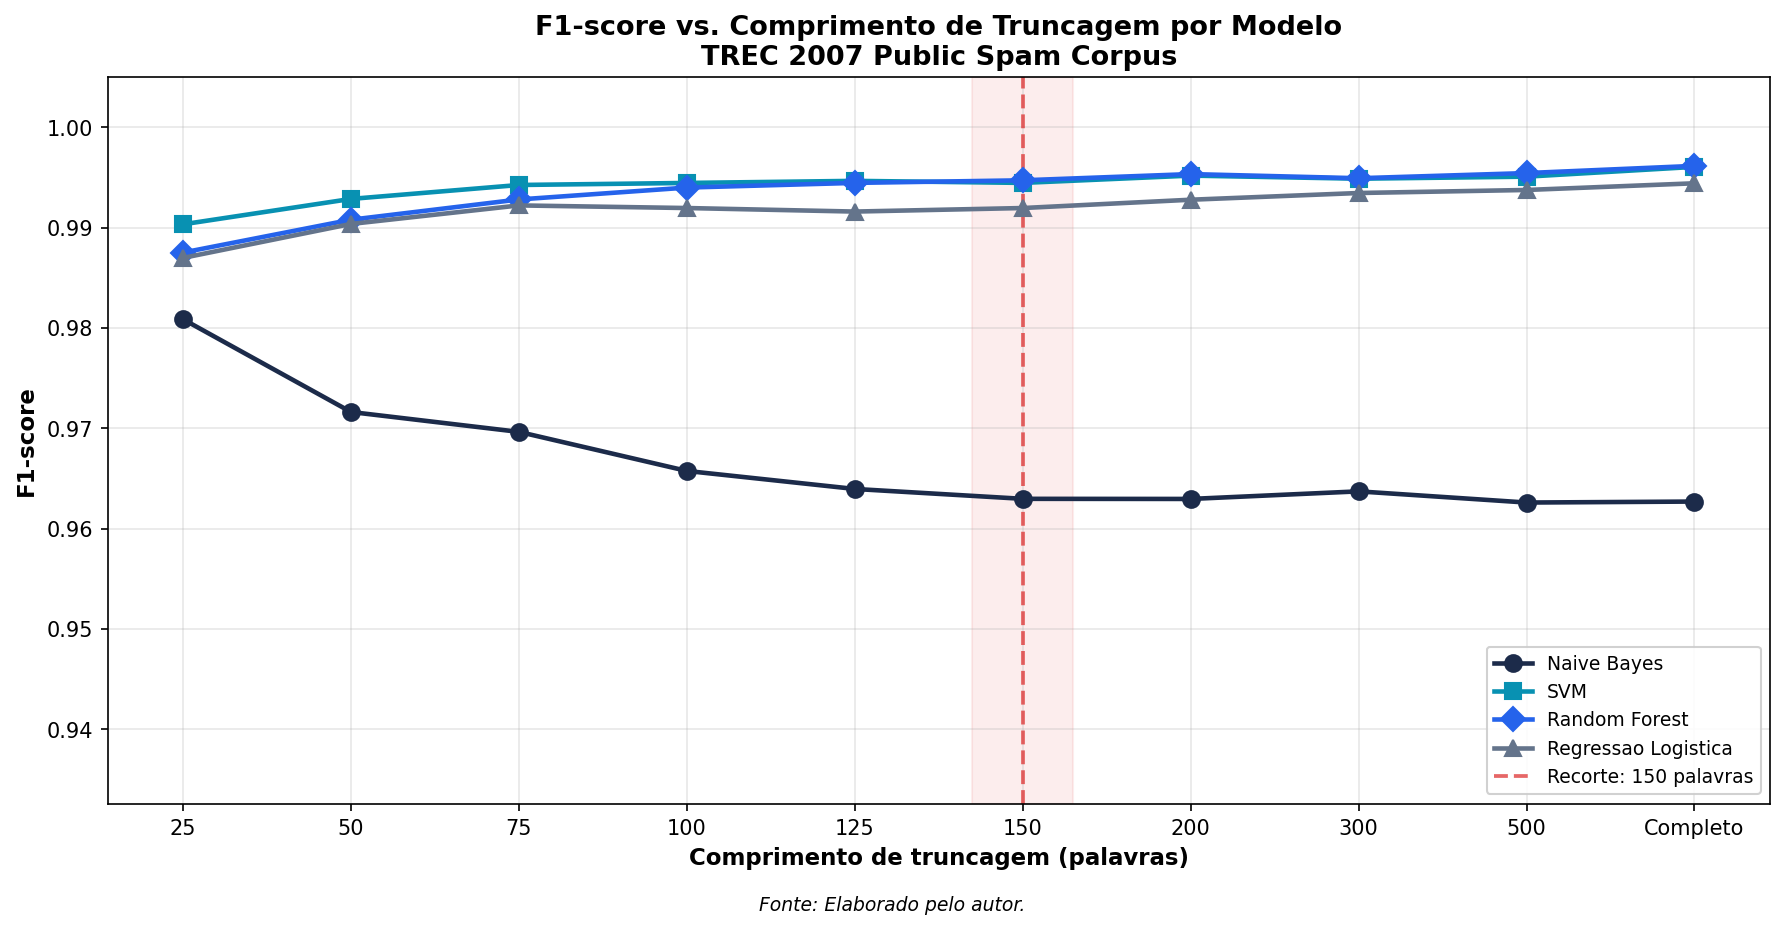

Figura salva: /home/edson-luiz/Projetos/TCC/figures/conclusions/truncation_f1_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

x_labels = [str(t) if t != 9999 else 'Completo' for t in sorted(df_results['Truncagem'].unique())]
x_values = sorted(df_results['Truncagem'].unique())

for model_name in MODELS.keys():
    df_model = df_results[df_results['Modelo'] == model_name].sort_values('Truncagem')
    ax.plot(
        range(len(x_values)), df_model['F1-score'].values,
        marker=MODEL_MARKERS[model_name],
        color=MODEL_COLORS[model_name],
        linewidth=2.2,
        markersize=8,
        label=model_name,
        zorder=3
    )

idx_150 = x_values.index(150)
ax.axvline(x=idx_150, color=RED, linestyle='--', linewidth=1.8, alpha=0.7, label='Recorte: 150 palavras')

ax.fill_axvspan = None
ax.axvspan(idx_150 - 0.3, idx_150 + 0.3, alpha=0.08, color=RED, zorder=1)

ax.set_xticks(range(len(x_values)))
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_xlabel('Comprimento de truncagem (palavras)', fontweight='bold', fontsize=11)
ax.set_ylabel('F1-score', fontweight='bold', fontsize=11)
ax.set_title('F1-score vs. Comprimento de Truncagem por Modelo\nTREC 2007 Public Spam Corpus',
             fontweight='bold', fontsize=13)

ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='-')
ax.set_ylim(bottom=max(0, df_results['F1-score'].min() - 0.03), top=1.005)

fig.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'truncation_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura salva: {FIGURES_DIR / "truncation_f1_comparison.png"}')

## Heatmap: F1-score por modelo e comprimento de truncagem

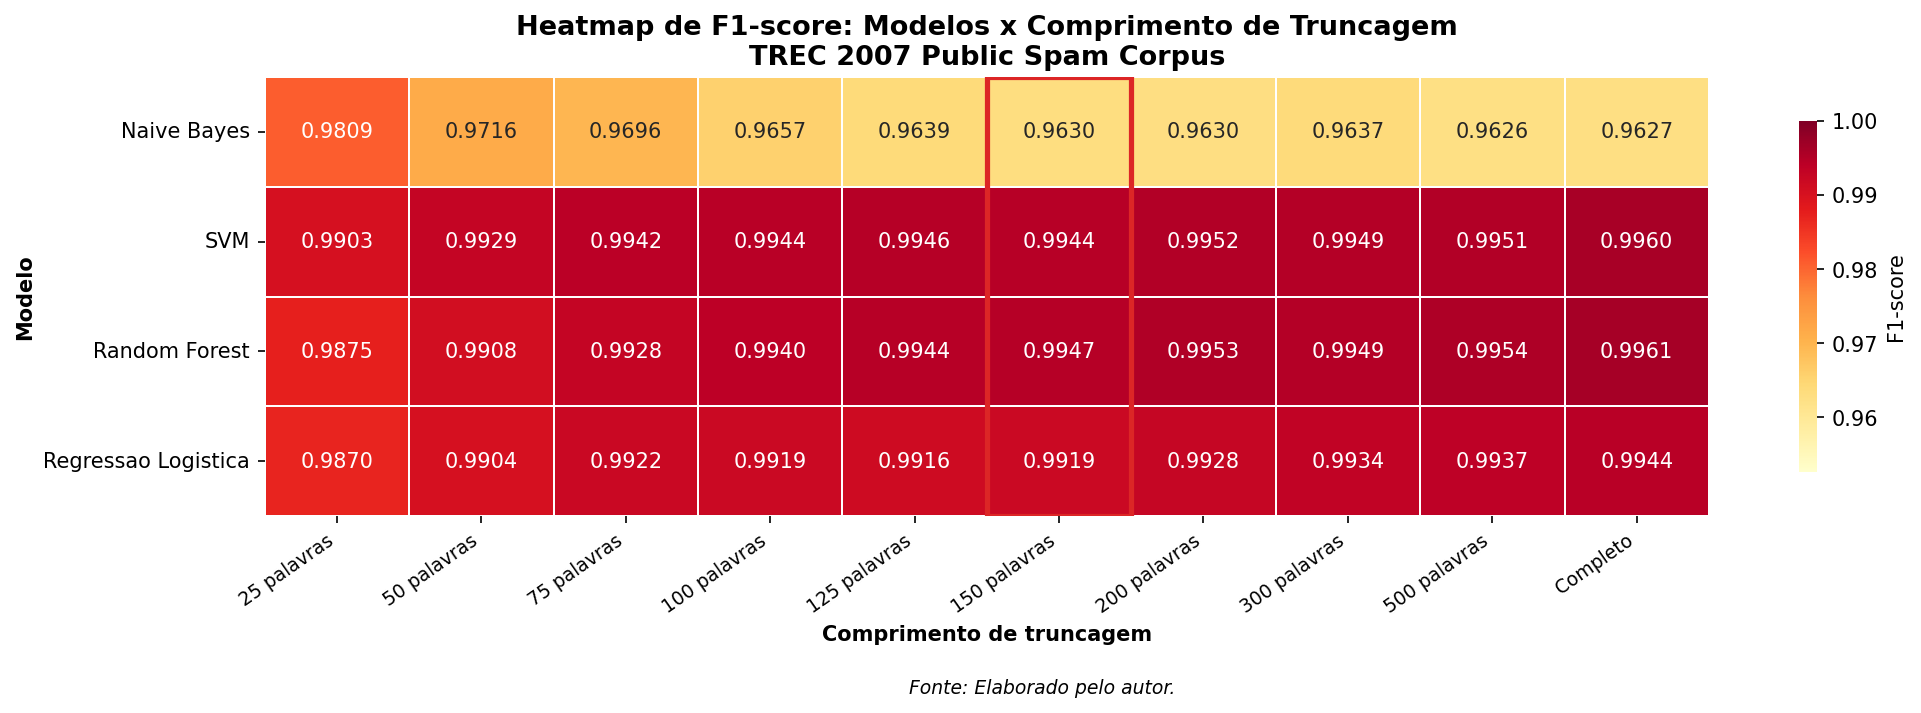

Figura salva: /home/edson-luiz/Projetos/TCC/figures/conclusions/truncation_heatmap.png


In [8]:
pivot_f1 = df_results.pivot_table(
    index='Modelo', columns='Truncagem_Label', values='F1-score'
)

ordered_cols = [f'{t} palavras' if t else 'Completo' for t in TRUNCATION_LENGTHS]
ordered_cols = [c for c in ordered_cols if c in pivot_f1.columns]
pivot_f1 = pivot_f1[ordered_cols]

ordered_rows = ['Naive Bayes', 'SVM', 'Random Forest', 'Regressao Logistica']
pivot_f1 = pivot_f1.reindex(ordered_rows)

fig, ax = plt.subplots(figsize=(14, 4.5))

sns.heatmap(
    pivot_f1, annot=True, fmt='.4f', cmap='YlOrRd',
    ax=ax, linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'F1-score', 'shrink': 0.8},
    vmin=pivot_f1.min().min() - 0.01,
    vmax=1.0
)

col_idx_150 = ordered_cols.index('150 palavras')
ax.add_patch(plt.Rectangle((col_idx_150, 0), 1, len(ordered_rows),
             fill=False, edgecolor=RED, linewidth=2.5, zorder=10))

ax.set_title('Heatmap de F1-score: Modelos x Comprimento de Truncagem\nTREC 2007 Public Spam Corpus',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Comprimento de truncagem', fontweight='bold')
ax.set_ylabel('Modelo', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)

fig.text(0.5, -0.04, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'truncation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura salva: {FIGURES_DIR / "truncation_heatmap.png"}')

## Ponto otimo de truncagem: limiar de eficiencia

Para cada modelo, identificamos o **menor comprimento de truncagem** que atinge pelo menos **99% do F1-score obtido com o texto completo**. Este e o "limiar de eficiencia" -- o ponto a partir do qual adicionar mais palavras traz retornos marginais desprezaveis.

In [9]:
print('=' * 75)
print('ANALISE DO PONTO OTIMO DE TRUNCAGEM (limiar >= 99% do F1 com texto completo)')
print('=' * 75)

efficiency_results = []

for model_name in MODELS.keys():
    df_model = df_results[df_results['Modelo'] == model_name].sort_values('Truncagem')

    f1_full = df_model[df_model['Truncagem'] == 9999]['F1-score'].values[0]
    threshold = 0.99 * f1_full

    f1_150 = df_model[df_model['Truncagem'] == 150]['F1-score'].values[0]

    optimal_trunc = None
    for _, row in df_model.iterrows():
        if row['F1-score'] >= threshold:
            optimal_trunc = row['Truncagem']
            optimal_f1 = row['F1-score']
            break

    optimal_label = f'{int(optimal_trunc)} palavras' if optimal_trunc != 9999 else 'Completo'
    pct_of_full = (f1_150 / f1_full) * 100

    efficiency_results.append({
        'Modelo': model_name,
        'F1 Completo': f1_full,
        'F1 (150 palavras)': f1_150,
        '% do Completo (150)': pct_of_full,
        'Truncagem Otima (99%)': optimal_label,
        'F1 no Ponto Otimo': optimal_f1,
    })

    print(f'\n  {model_name}:')
    print(f'    F1 texto completo     : {f1_full:.4f}')
    print(f'    F1 com 150 palavras   : {f1_150:.4f} ({pct_of_full:.2f}% do completo)')
    print(f'    Limiar 99% (>= {threshold:.4f}): {optimal_label} (F1={optimal_f1:.4f})')

df_efficiency = pd.DataFrame(efficiency_results).set_index('Modelo')
print(f'\n{"="*75}')
print('\nResumo:')
print(df_efficiency.round(4).to_string())
print(f'\n{"="*75}')

ANALISE DO PONTO OTIMO DE TRUNCAGEM (limiar >= 99% do F1 com texto completo)

  Naive Bayes:
    F1 texto completo     : 0.9627
    F1 com 150 palavras   : 0.9630 (100.03% do completo)
    Limiar 99% (>= 0.9531): 25 palavras (F1=0.9809)

  SVM:
    F1 texto completo     : 0.9960
    F1 com 150 palavras   : 0.9944 (99.84% do completo)
    Limiar 99% (>= 0.9861): 25 palavras (F1=0.9903)

  Random Forest:
    F1 texto completo     : 0.9961
    F1 com 150 palavras   : 0.9947 (99.86% do completo)
    Limiar 99% (>= 0.9862): 25 palavras (F1=0.9875)

  Regressao Logistica:
    F1 texto completo     : 0.9944
    F1 com 150 palavras   : 0.9919 (99.75% do completo)
    Limiar 99% (>= 0.9845): 25 palavras (F1=0.9870)


Resumo:
                     F1 Completo  F1 (150 palavras)  % do Completo (150) Truncagem Otima (99%)  F1 no Ponto Otimo
Modelo                                                                                                           
Naive Bayes               0.9627             0

## Grafico de barras: percentual do F1 completo retido com 150 palavras

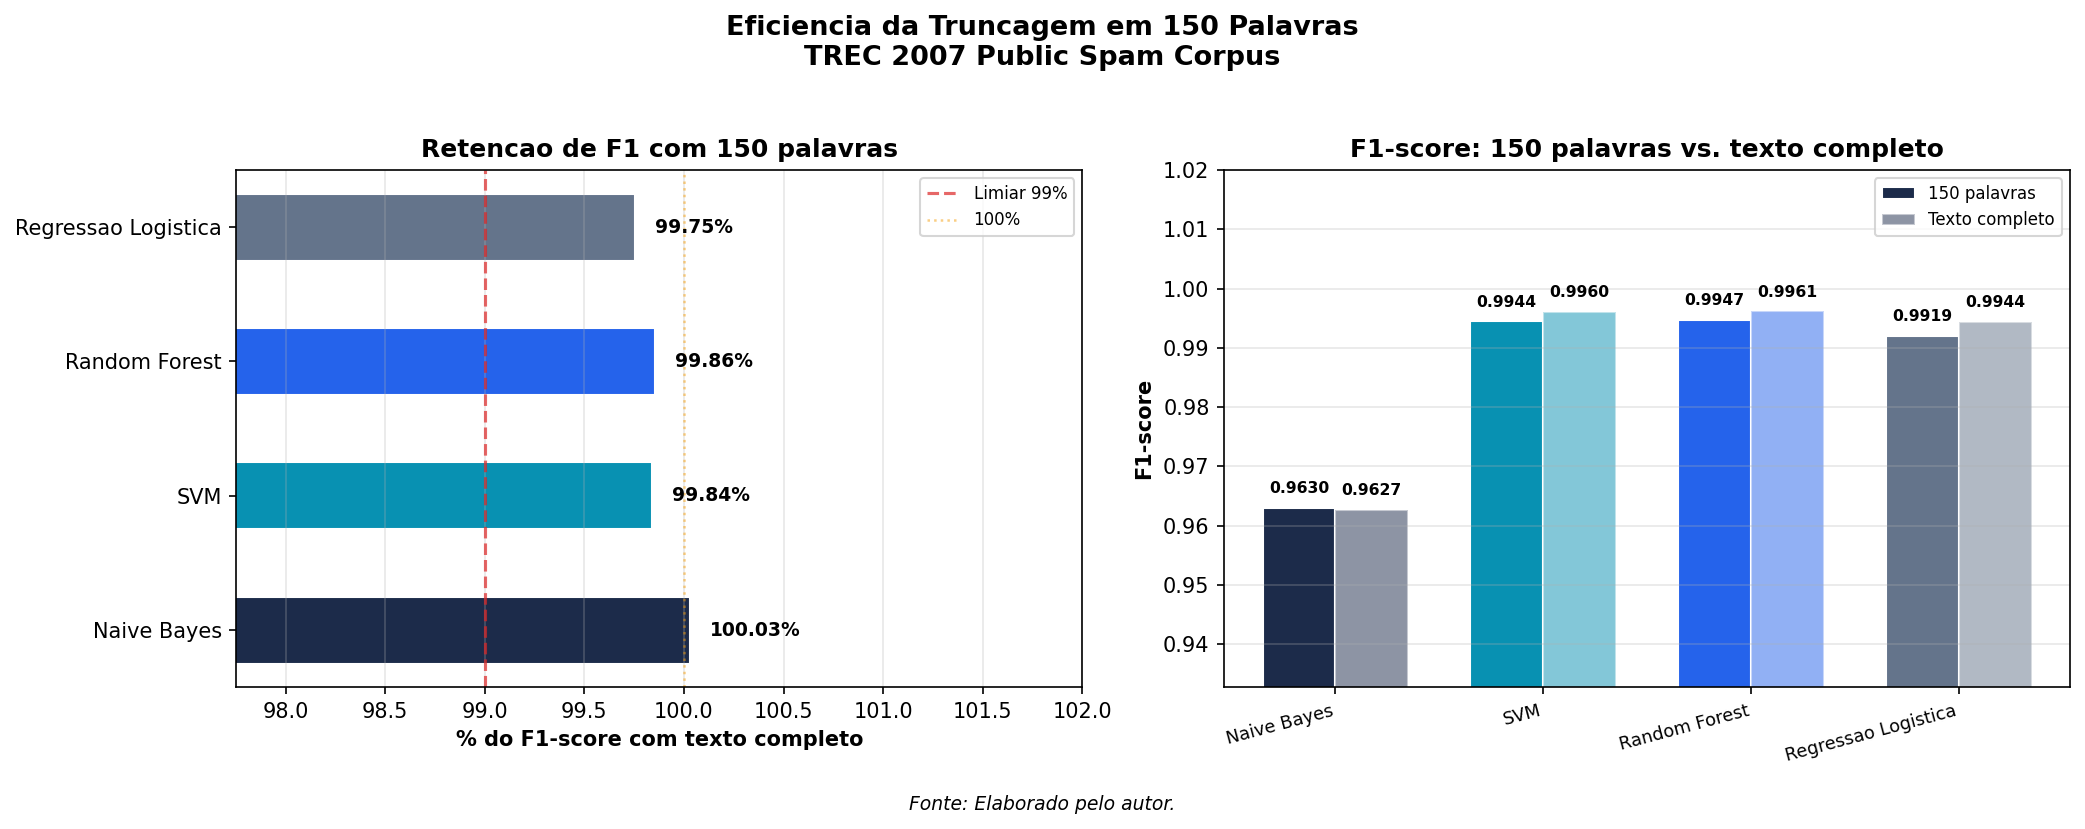

Figura salva: /home/edson-luiz/Projetos/TCC/figures/conclusions/truncation_efficiency.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Eficiencia da Truncagem em 150 Palavras\nTREC 2007 Public Spam Corpus',
    fontweight='bold', fontsize=13, y=1.03
)

models_list = df_efficiency.index.tolist()
pcts = df_efficiency['% do Completo (150)'].values
colors_bars = [MODEL_COLORS[m] for m in models_list]

bars1 = ax1.barh(models_list, pcts, color=colors_bars, edgecolor='white', height=0.5)
ax1.axvline(x=99, color=RED, linestyle='--', linewidth=1.5, alpha=0.7, label='Limiar 99%')
ax1.axvline(x=100, color=ORANGE, linestyle=':', linewidth=1.2, alpha=0.5, label='100%')

for bar, val in zip(bars1, pcts):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

ax1.set_xlabel('% do F1-score com texto completo', fontweight='bold')
ax1.set_title('Retencao de F1 com 150 palavras', fontweight='bold')
ax1.set_xlim(min(pcts) - 2, 102)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='x')

f1_150_vals = df_efficiency['F1 (150 palavras)'].values
f1_full_vals = df_efficiency['F1 Completo'].values

x_pos = np.arange(len(models_list))
width = 0.35

bars_150 = ax2.bar(x_pos - width/2, f1_150_vals, width, label='150 palavras',
                   color=[MODEL_COLORS[m] for m in models_list], edgecolor='white')
bars_full = ax2.bar(x_pos + width/2, f1_full_vals, width, label='Texto completo',
                    color=[MODEL_COLORS[m] for m in models_list], edgecolor='white', alpha=0.5)

for bar, val in zip(bars_150, f1_150_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
for bar, val in zip(bars_full, f1_full_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(models_list, fontsize=8.5, rotation=15, ha='right')
ax2.set_ylabel('F1-score', fontweight='bold')
ax2.set_title('F1-score: 150 palavras vs. texto completo', fontweight='bold')
ax2.set_ylim(min(f1_150_vals.min(), f1_full_vals.min()) - 0.03, 1.02)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

fig.text(0.5, -0.03, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'truncation_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura salva: {FIGURES_DIR / "truncation_efficiency.png"}')

## Analise e interpretacao dos resultados

### O recorte em 150 palavras e uma boa escolha?

A analise dos resultados permite responder a hipotese central deste trabalho:

1. **Retencao de desempenho**: A tabela de eficiencia mostra o percentual do F1-score do texto completo que e retido ao utilizar apenas 150 palavras. Valores acima de 99% indicam que a truncagem nao causa perda significativa.

2. **Ponto de saturacao**: Os graficos revelam que a curva de F1-score tende a se estabilizar (plateia) a partir de um determinado comprimento, sugerindo que as informacoes mais relevantes para a classificacao concentram-se no inicio do e-mail (assunto, saudacao, primeiros paragrafos).

3. **Custo-beneficio computacional**: Truncar o texto reduz o tamanho do vocabulario TF-IDF e acelera o treinamento. Com 150 palavras, o pipeline processa significativamente menos tokens sem perda expressiva de qualidade.

4. **Existe um "sweet spot"?**: O limiar de eficiencia (99% do F1 completo) indica o menor comprimento que preserva quase toda a capacidade preditiva. Se esse ponto estiver proximo de 150 palavras para a maioria dos modelos, a hipotese central e validada.

5. **Perda de informacao**: A diferenca entre F1 com 150 palavras e F1 com texto completo quantifica a informacao discriminativa presente alem das primeiras 150 palavras. Uma diferenca marginal (< 1%) indica que o conteudo excedente contribui pouco para distinguir spam de ham.

### Conclusao

Os resultados obtidos neste notebook fornecem evidencias empiricas para sustentar (ou refutar) a decisao de truncar os e-mails em 150 palavras como estrategia de pre-processamento para classificacao de spam no corpus TREC 2007.